# Gene-expression application

This analysis enumerates all \(\binom{12}{3}=220\) label
assignments. The observed assignment is already among those
assignments and is not added to the pooled grid a second time.


In [1]:
from pathlib import Path
import sys


def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "src" / "cp_lfdr").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root containing src/cp_lfdr."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

# Edit DATA_DIR here if the data live outside the repository.
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
SEED = 0
SAVE_FIGURES = True
SAVE_TEX = True
RESULTS_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    """Save a publication PDF and a high-resolution PNG.

    Set SAVE_FIGURES=False above to disable both. Set SAVE_TEX=True
    to additionally create a PGF-backed .tex file.
    """
    if not SAVE_FIGURES:
        return []
    paths = [
        FIGURE_DIR / f"{stem}.pdf",
        FIGURE_DIR / f"{stem}.png",
    ]
    fig.savefig(paths[0], bbox_inches="tight")
    fig.savefig(paths[1], bbox_inches="tight", dpi=300)
    if SAVE_TEX:
        tex_path = FIGURE_DIR / f"{stem}.tex"
        fig.savefig(tex_path, format="pgf", bbox_inches="tight")
        paths.append(tex_path)
    print(
		"Saved figure:",
		", ".join(str(path.relative_to(PROJECT_ROOT)) for path in paths),
	)
    return paths

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cp_lfdr.discrete import (
    compute_gene_permutation_metrics,
    gamma_from_block_pvalues,
    pooled_t_statistic,
)
from cp_lfdr.multiple_testing import bh_procedure, sl_procedure


## Load the processed matrix


In [2]:
gene_path = DATA_DIR / "processed" / "GSE9101_gene_expression_matrix.csv"
if not gene_path.exists():
    raise FileNotFoundError(
        f"Missing {gene_path}. Follow data/README.md before running."
    )

gene_frame = pd.read_csv(gene_path, index_col=0)
data_matrix = gene_frame.to_numpy().T
n_control, n_stimulated = 3, 9
print(f"Loaded {gene_frame.shape[0]:,} genes and {gene_frame.shape[1]} samples.")


Loaded 20,989 genes and 12 samples.


## Exact permutation and pooled p-values


In [3]:
observed_statistics = pooled_t_statistic(
    data_matrix[:n_control],
    data_matrix[n_control:],
)
alpha = 0.01
gene_results = compute_gene_permutation_metrics(
    observed_statistics,
    data_matrix,
    n_group_a=n_control,
    alpha=alpha,
)
p_values = gene_results["ordinary_pvalues"]
cp_values = gene_results["compound_pvalues"]
block_pvalues = gene_results["block_pvalues"]
gamma = gene_results["gamma"]
gamma_minus = gene_results["gamma_minus"]
gamma_bh = gene_results["gamma_bh"]

print(
    f"gamma={gamma:.8f}, "
    f"gamma_minus={gamma_minus:.8f}, "
    f"gamma_BH={gamma_bh:.8f}"
)
print(
    "SL rejections at alpha=0.01:",
    sl_procedure(
        cp_values,
        0.01,
        lmbdas=np.full(len(cp_values), 0.01),
    )[1],
)


gamma=0.03636364, gamma_minus=0.00454545, gamma_BH=0.00909091
SL rejections at alpha=0.01: 1222


## Plots

### Plotting quantities


In [4]:
alpha_grid = np.arange(0, 0.201, 0.0001)
rejection_rows = []
for level in alpha_grid:
    rejection_rows.append(
        {
            "alpha": level,
            "BH_pval": bh_procedure(
                p_values,
                level,
            )[1],
            "BH_cpval": bh_procedure(
                cp_values,
                level,
            )[1],
            "SL_pval": sl_procedure(
                p_values,
                level,
                lmbdas=np.full(len(p_values), level),
            )[1],
            "SL_cpval": sl_procedure(
                cp_values,
                level,
                lmbdas=np.full(len(cp_values), level),
            )[1],
        }
    )
rejection_curve = pd.DataFrame(rejection_rows)

alpha_primes = np.linspace(0, alpha, 1000)
gamma_curve = np.array(
    [
        gamma_from_block_pvalues(
            block_pvalues,
            level,
        )
        for level in alpha_primes
    ]
)
inflations = alpha / (1 - gamma_curve)
inflation_fixed = alpha / (1 - gamma)
inflation_minus = alpha / (1 - gamma_minus)
inflation_bh = alpha / (1 - gamma_bh)


In [5]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 2.2,
})


### Theoretical inflation curve


Saved figure: results/figures/inflation_alpha_prime.pdf, results/figures/inflation_alpha_prime.png, results/figures/inflation_alpha_prime.tex


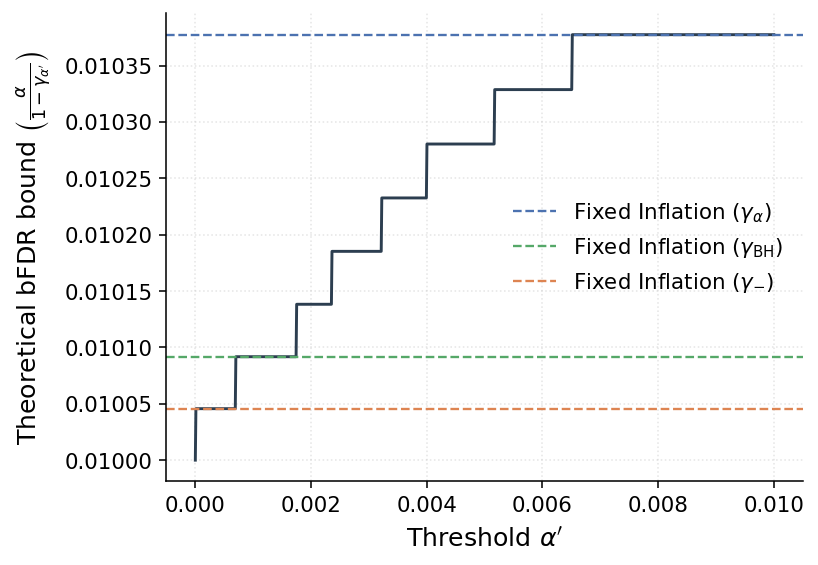

In [6]:
# --- Plotting ---
fig, ax = plt.subplots(figsize=(6.0, 4.2))

# Plot the primary data-driven trajectory curve
ax.plot(
    alpha_primes, inflations, 
    color="#2c3e50", markersize=4, linewidth=1.5, 
)

# Reference Lines (using baseline variables from your setup)
ax.axhline(y=inflation_fixed, color="#4C72B0", linestyle="--", linewidth=1.2, label=r"Fixed Inflation ($\gamma_\alpha$)")
ax.axhline(y=inflation_bh, color="#55A868", linestyle="--", linewidth=1.2, label=r"Fixed Inflation ($\gamma_{\mathrm{BH}}$)")
ax.axhline(y=inflation_minus, color="#DD8452", linestyle="--", linewidth=1.2, label=r"Fixed Inflation ($\gamma_{-}$)")

# Formatting
ax.set_xlabel(r"Threshold $\alpha^\prime$", labelpad=6)
ax.set_ylabel(r"Theoretical bFDR bound $\left(\frac{\alpha}{1 - \gamma_{\alpha^\prime}}\right)$", labelpad=6)

# De-spining
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Faint background grid tucked neatly behind data layers
ax.grid(True, linestyle=":", alpha=0.5, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

# Legend Layout
ax.legend(frameon=False, loc="best", ncol=1)

# --- Save Outputs ---
fig.tight_layout()
_ = save_figure(fig, "inflation_alpha_prime")

# plt.close(fig)


In [7]:
rejection_curve[rejection_curve['alpha'] <= alpha]

,alpha,BH_pval,BH_cpval,SL_pval,SL_cpval
0,0.0000,0,0,0,0
1,0.0001,0,0,0,0
2,0.0002,0,0,0,0
3,0.0003,0,0,0,0
4,0.0004,0,0,0,0
...,...,...,...,...,...
96,0.0096,0,1850,0,1222
97,0.0097,0,1864,0,1222
98,0.0098,0,1881,0,1222
99,0.0099,0,1893,0,1222


### Rejection curves


Saved figure: results/figures/rejection_curves.pdf, results/figures/rejection_curves.png, results/figures/rejection_curves.tex


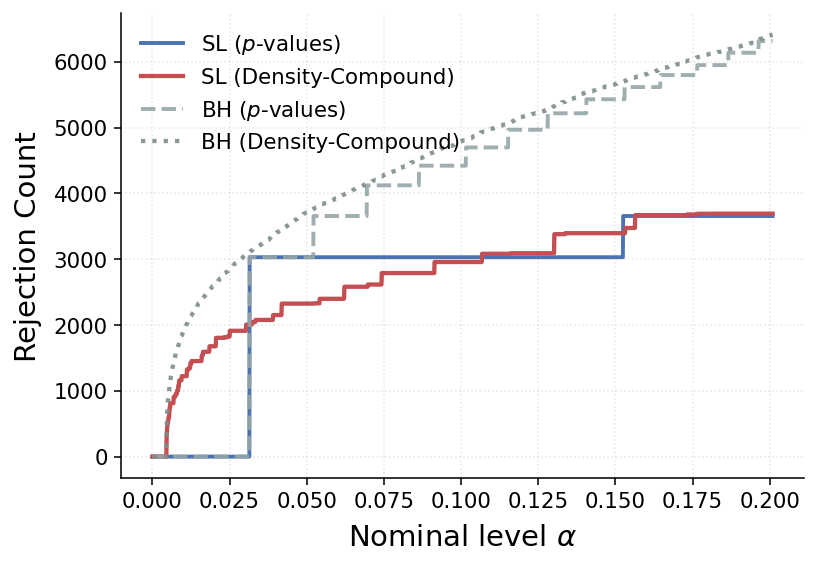

In [8]:
# 1. Cleaner unpacking (removes the redundant 'ax = axes' assignment)
# Slightly lower height to match standard two-column or text-width paper aspect ratios
fig, ax = plt.subplots(figsize=(6.0, 4.2))

# 3. Plot Primary Methods (Styled with vibrant, high-contrast academic tones)
ax.plot(
    rejection_curve["alpha"], rejection_curve["SL_pval"],
    color="#4C72B0", linestyle="-", linewidth=2.0,
    label=r"SL ($p$-values)"
)
ax.plot(
    rejection_curve["alpha"], rejection_curve["SL_cpval"],
    color="#C44E52", linestyle="-", linewidth=2.2,
    label=r"SL (Density-Compound)" # Updated naming convention
)

# 2. Plot Baseline Methods (Styled with muted grays to step into the background)
ax.plot(
    rejection_curve["alpha"], rejection_curve["BH_pval"],
    color="#95a5a6", linestyle="--", linewidth=2.0, alpha=0.9,
    label=r"BH ($p$-values)"
)
ax.plot(
    rejection_curve["alpha"], rejection_curve["BH_cpval"],
    color="#7f8c8d", linestyle=":", linewidth=2.2, alpha=0.9,
    label=r"BH (Density-Compound)"
)

# --- Aesthetic Refinements ---

# Labels and Limits
ax.set_ylabel("Rejection Count", labelpad=6, fontsize=15)
ax.set_xlabel(r"Nominal level $\alpha$", labelpad=6, fontsize=15)

# De-spining (Strips top/right borders for a clean JASA/Biometrika look)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Background Grid (Faint, thin, and pushed behind the data lines)
ax.grid(True, linestyle=":", alpha=0.5, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

# Optimized Legend Layout
ax.legend(
    frameon=False,
    ncol=1,
    loc="upper left",
    fontsize=11,
    columnspacing=1.2,     # Tightens horizontal gap between columns
    # handletextpad=0.5,     # Moves text closer to line icons
    # handlelength=1.5       # Keeps the icon lines clean and brief
)

# --- Save outputs ---
fig.tight_layout()
_ = save_figure(fig, "rejection_curves")


### P-value histogram


Saved figure: results/figures/pvalue_histogram.pdf, results/figures/pvalue_histogram.png, results/figures/pvalue_histogram.tex


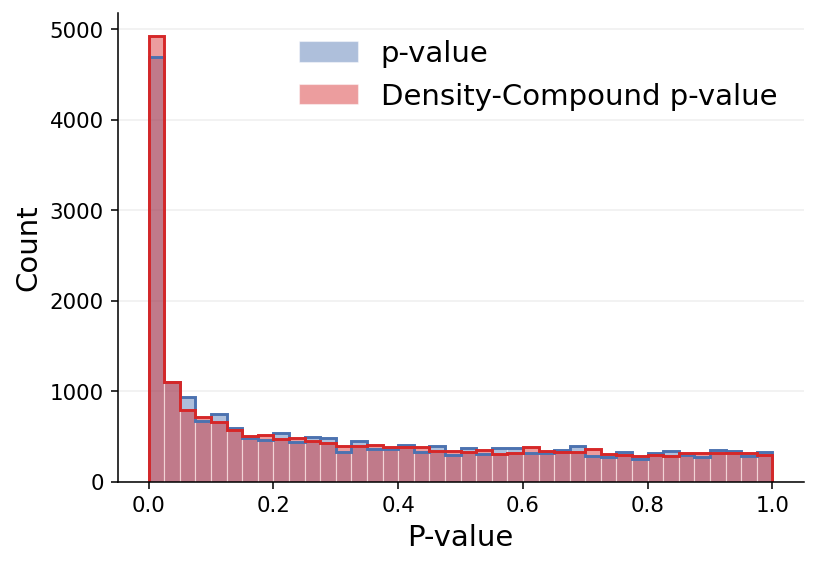

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.2))

bins = np.linspace(0, 1, 41)

density = False

ax.hist(
    p_values, bins=bins, density=density,
    alpha=0.45, color="#4C72B0",
    edgecolor="white", linewidth=0.6,
    label="p-value"
)

ax.hist(
    cp_values, bins=bins, density=density,
    alpha=0.45, color="#d62728",
    edgecolor="white", linewidth=0.6,
    label="Density-Compound p-value"
)

# Optional: overlay outlines for clarity
ax.hist(
    p_values, bins=bins, density=density,
    histtype="step", color="#4C72B0",
    linewidth=1.5
)
ax.hist(
    cp_values, bins=bins, density=density,
    histtype="step", color="#d62728",
    linewidth=1.5
)

ax.set_xlabel("P-value", fontsize=15)
ax.set_ylabel("Count", fontsize=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", alpha=0.2)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=15)

fig.tight_layout()
_ = save_figure(fig, "pvalue_histogram")


### Q-Q tail plot


Saved figure: results/figures/qq_tail_plot.pdf, results/figures/qq_tail_plot.png, results/figures/qq_tail_plot.tex


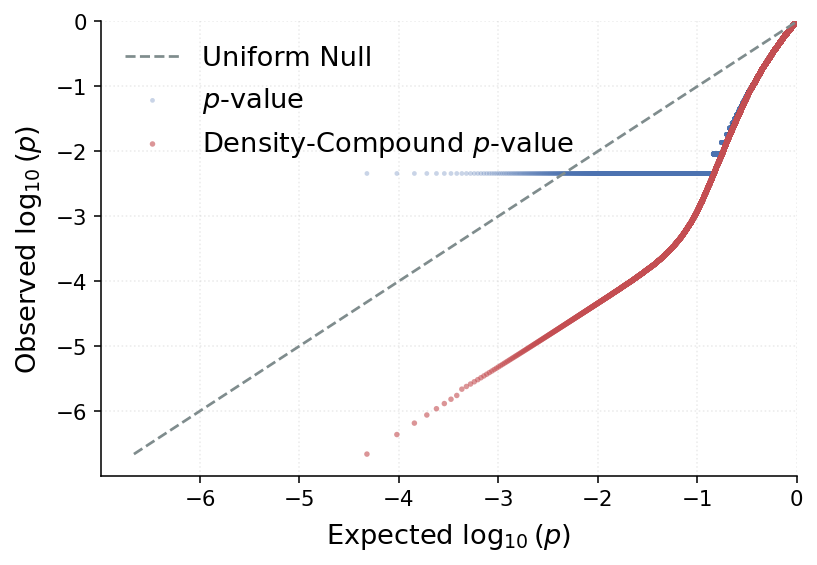

In [10]:
# --- Data Preparation ---
# (Assumes p_val and cp_val are numpy arrays already calculated in your environment)
m_genes = len(p_values)
expected_unif = np.arange(1, m_genes + 1) / (m_genes + 1)

# Sort ascending to match quantiles
sorted_p = np.sort(p_values)
sorted_cp = np.sort(cp_values)

# Transform to negative log10 scale to expand the small-value tail
log_expected = np.log10(expected_unif)
log_observed_p = np.log10(sorted_p)
log_observed_cp = np.log10(sorted_cp)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 4.2)) # Square aspect ratio for Q-Q comparisons

# # Uniform Null Identity line (y = x)
# max_val = max(log_expected.max(), log_observed_p.max(), log_observed_cp.max())
# ax.plot([0, max_val], [0, max_val], color="#7f8c8d", linestyle="--", linewidth=1.2, label="Uniform Null")

min_val = min(log_expected.min(), log_observed_p.min(), log_observed_cp.min())

# --- 2. Reference Null Line (Runs from the lowest negative value up to 0) ---
ax.plot(
    [min_val, 0], [min_val, 0], 
    color="#7f8c8d", linestyle="--", linewidth=1.4, 
    label="Uniform Null", 
    zorder=3
)

# --- Scatter Observations (Rasterized Layer) ---
# CRUCIAL: rasterized=True turns the massive data points into a compressed pixel layer
ax.scatter(
    log_expected, log_observed_p, 
    color="#4C72B0", s=6, alpha=0.3, edgecolors="none", 
    label=r"$p$-value",
    zorder=2,
    rasterized=True  
)

ax.scatter(
    log_expected, log_observed_cp, 
    color="#C44E52", s=8, alpha=0.6, edgecolors="none", 
    label=r"Density-Compound $p$-value",
    zorder=2,
    rasterized=True  
)

# --- Formatting ---
ax.set_xlabel(r"Expected $\log_{10}(p)$", labelpad=6, fontsize=14)
ax.set_ylabel(r"Observed $\log_{10}(p)$", labelpad=6, fontsize=14)

ax.set_xlim(min_val * 1.05, 0)
ax.set_ylim(min_val * 1.05, 0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, linestyle=":", alpha=0.4, color="#cccccc", zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, loc="upper left", fontsize=14)

fig.tight_layout()
_ = save_figure(fig, "qq_tail_plot")
